
# Tasca 2. Mètodes iteratius
Volem resoldre el sistema lineal
$$
 A x = b,
$$
on $A$ és una matriu real $n\times n$ no singular, pels mètodes iteratius de

1. Jacobi. 
2. Gauss-Seidel. 
3. Sobre-relaxació successiva (SOR).
4. Mètode del màxim descens, del gradient o del pendent màxim.
5. Mètode del gradient conjugat 

* Per als mètodes 1 i 2 llegirem les matrius $A$ i $b$ del fitxer `sistemaedd.npz`.
* Per als mètodes 3, 4 i 5 llegirem la matrius $A$ i $b$ del fitxer `sistemasdp.npz`.
* A més, per al mètode de sobre-relaxació successiva buscarem el valor "òptim" del
paràmetre $\omega$.

In [1]:
import numpy as np
from enum import Enum

from numpy import load
from numpy import array
from numpy import int64
from numpy import float64
from numpy import linspace
from numpy import meshgrid
from numpy import sort
from numpy.linalg import inv
import matplotlib.pyplot as plt

from metodes_iteratius import MetodeIteratiu, EstatMetodeIteratiuDescomposicio

from fitxers import Fitxers, DIRECTORI_DADES
from utils import radi_espectral

class AproximacioInicial(Enum):
    """
    Enumerador que representa les aproximacions iniciales del sistema.
    """
    ZERO = 0
    """
    Començar amb un vector nul.
    """
    TERME_INDEPENDENT = 1
    """
    Començar amb el terme independent del sistema, b.
    """


def llegir_matrius(fitxer: Fitxers) -> tuple[np.ndarray, np.ndarray]:

    path = DIRECTORI_DADES + fitxer  # Fitxer amb les matrius A i b, A edd

    # ###################################################################

    # Llegim les dades del fitxer sistemaedd.npz, que conté la matriu del
    # sistema, A, i el terme independent, b

    data = load(path)
    print(f"Fichero: {path}\nClaves: {data.files}\n")
    A = data[data.files[0]]
    b = data[data.files[1]]
    data.close() # Tanquem el fitxer un cop s'han llegit les dades


    # Dimensions de les matrius A i b:
    num_files_A, num_cols_A = A.shape
    print(f"Dimensions de la matriu A: {num_files_A} x {num_cols_A}")
    num_files_b, num_cols_b = b.shape
    print(f"Dimensions de la matriu b: {num_files_b} x {num_cols_b}\n")

    return A, b


def imprimir_resultats(metode: MetodeIteratiu):

    print("Mètode:", metode.__class__.__name__)
    print(f"Nombre màxim d'iterats: nitm = {metode.nitm:4d}")
    print(f"Precisio: tol = {metode.tol:9.4e}\n")

    if isinstance(metode.estat, EstatMetodeIteratiuDescomposicio):
        # Es tracta d'un mètode iteratiu basat en una descomposició regular

        matriu_iteracio_ = metode.estat.matriu_iteracio()
        print("Radi espectral de la matriu d\'iteració: " +
              f"{radi_espectral(matriu_iteracio_):5.3f}")

    assert metode.estat is not None
    r, num_it_conv = metode.estat.residu(), metode.estat.k

    if num_it_conv > 0:
        print(f"Iterats: {num_it_conv}, " +
              f"||r|| = {r:9.5e} < " +
              f"tol * ||b|| = {metode.tol * np.linalg.norm(b, ord=2):9.5e}")
    else:
        print(f"Iterats: {metode.nitm}, " +
              f"||r|| = {r:9.5e} >= " +
              f"tol * ||b|| = {metode.tol * np.linalg.norm(b, ord=2):9.5e}:\n" +
              f"\t No hi ha convergència en {nitm} iterats!")

### Referències
* [[AK2008]](
 https://discovery.upc.edu/permalink/34CSUC_UPC/i7glq6/alma991003873489706711) 
 G. Allaire; S. M. Keber. Springer, New York, 2008.
* [[dCNL10]](https://ocw-camins.upc.edu/materials_guia/250402/2023/iterativos_v1.pdf)
  Laboratori de Càlcul Numèric UPC (LaCàN), 2010.
* [Python 3.14.4 documentation](https://docs.python.org/3/)
* [NumPy user guide](https://numpy.org/doc/stable/user/index.html#user)
* [Matplotlib 3.10.9 documentation](https://matplotlib.org/stable/index.html) 
  


### Mètodes iteratius
Considerem una _descomposició regular_ o _splitting_ de la matriu $A$. Això és,
una parella $(M, N)$ de matrius reals $n\times n$, amb $M$ no singular, tals que:
$A = M - N$.

Definim el _mètode iteratiu_ associat a aquesta descomposició com,
$$
\begin{array}{cc}
(1):\left\{
   \begin{align*}
      x_{0} &\in\mathbb{R}^{n},\\
      M x_{k+1} &= N x_{k} + b,\quad k\ge 0,
   \end{align*}
\right. &\qquad\qquad
(2):\left\{
\begin{align*}
   x_{0} &\in\mathbb{R}^{n},\\
   x_{k+1} &= M^{-1} N x_{k} + M^{-1} b,\quad k\ge 0, 
\end{align*}
\right.
\end{array}
$$

#### Algorisme
([ [AK2008] ](
https://discovery.upc.edu/permalink/34CSUC_UPC/i7glq6/alma991003873489706711), 
Sec. 8.6)
```pseudocode
Algorisme MetodeIteratiu 

   * Input: 
   *     A: matriu del sistema
   *     b: terme independent
   *     x: aproximació inicial de la solució
   *     omega: paràmetre de sobre-relaxació (si cal)
   *     tol: error relatiu (respecte del residu inicial)
   *     nitm: nombre màxim d'iteracions
   * Output:
   *     x: solució aproximada
   *     r: últim valor trobat de la norma del residu
   *   nit: nombre d'itracions. Si no hi ha convergència nit = -1
   
   Inicialitzem el contador d'iterats nit = 0
   Calculem el residu r = b - A x
   While norma2(r) > tol * norma2(b) 
         nit = nit + 1
         If nit > nitm
            nit = - 1
            break
         endIf 

         Calculem la solució de M y = r

         x = x + y
         r = r - Ay
   endWhile
   return x, norm2(r), nit  
FinalAlgorisme
```


### Mètode de Jacobi
$$
  M = D = \mathrm{diag}[a_{1,1}, a_{2,2},\dots,a_{n,n}],
\qquad N = A - D
$$
Matriu d'iteració:
$$
\mathcal{J} = M^{-1} N = D^{-1} (A - D)
$$

### Exercici 11
Llegiu la matriu $A$ (estrictament diagonal dominant) i el vector $b$ del fitxer
`sistemaedd.npz` amb les instruccions:
```Python
from numpy import load
file = "sistemaedd.npz"
data = load(file)
print(f"Fichero: {file}\nClaves: {data.files}\n")
A = data[data.files[0]]
print(f"Matriu A:\n{A}\n")
b = data[data.files[1]]
print(f"Vector b:\n{b}\n")
data.close() # Cal que tanqueu el fitxer un cop s'han llegit les dades
```
1. Cridem la funció `radi_espectral` per a calcular el radi espectral de la
matriu d'iteració $\mathcal{J}$, $\rho\left(\mathcal{J}\right)$.

2. Cridem la funció `jacobi` per a resoldre el sistema 
$$
     A x = b.
$$

3. Amb la instrucció `print` treieu per pantalla almenys les següents dades i resultats: 

    - Les dimensions de les matrius $A$ i $b$.

    - El nombre màxim d'iterats permesos.

    - La precisió relativa, $\varepsilon$, demanada.

    - El radi espectral de la matriu de iteració, $\rho\left(\mathcal{J}\right)$.

    - El nombre d'iterats que s'han executat.
      
    - La norma del residu de l'última aproximació calculada de la solució.

    - El producte de la tolerància relativa, $\varepsilon$, per la norma de $b$.

    - Un missatge indicant si no s'ha assolit la precisió relativa requerida en
      el nombre d'iterats permesos.


### Solució

In [2]:
# ###################################################################
# Mètode de Jacobi
# ###################################################################
from metodes_iteratius import Jacobi

tol = 1.0e-14            # Precisió relativa demanada
nitm = 100000             # Nombre màxim d'iterats permesos

A, b = llegir_matrius("sistemaedd.npz")

n = b.shape[0]

jacobi = Jacobi(tol, nitm)
jacobi.resoldre(A, b, np.zeros((n,1)))

imprimir_resultats(jacobi)


Fichero: data/sistemaedd.npz
Claves: ['matriu_sistema', 'vector']

Dimensions de la matriu A: 50 x 50
Dimensions de la matriu b: 50 x 1

Mètode: Jacobi
Nombre màxim d'iterats: nitm = 100000
Precisio: tol = 1.0000e-14

Radi espectral de la matriu d'iteració: 0.961
Iterats: 799, ||r|| = 4.15387e-14 < tol * ||b|| = 4.26420e-14


### Mètode de Gauss-Seidel
$$
  M = D - E,\qquad N = F.
$$
Essent:
* $\phantom{-}D$: part diagonal de la matriu $a$, i.e.: $D =
  \mathrm{diag}[a_{1,1}, a_{2,2},\dots, a_{n,n}]$.
* $-E$: part triangular inferior estricta de la matriu $A$.
* $-F$: part triangular superior estricta de la matriu $A$.  

Matriu d'iteració:
$$
\mathcal{G}_{1} = M^{-1} N = (D-E)^{-1}F.
$$

### Exercici 12
Llegiu la matriu $A$ (estrictament diagonal dominant) i el vector $b$ del fitxer
`sistemaedd.npz` amb les instruccions:
```Python
from numpy import load
file = "sistemaedd.npz"
data = load(file)
print(f"Fichero: {file}\nClaves: {data.files}\n")
A = data[data.files[0]]
print(f"Matriu A:\n{A}\n")
b = data[data.files[1]]
print(f"Vector b:\n{b}\n")
data.close() # Cal que tanqueu el fitxer un cop s'han llegit les dades
```
1. Cridem la funció `radi_espectral` per a calcular el radi espectral de la
matriu d'iteració $\mathcal{G}_{1}$, $\rho\left(\mathcal{G}_{1}\right)$.

2. Cridem la funció `gauss_seidel` per a resoldre el sistema 
$$
     A x = b.
$$

3. Amb la instrucció `print` treieu per pantalla almenys les següents dades i resultats: 

    - Les dimensions de les matrius $A$ i $b$.

    - El nombre màxim d'iterats permesos.

    - La precisió demanada, $\varepsilon$. 

    - El radi espectral de la matriu de iteració, $\rho\left(\mathcal{G}_{1}\right)$.

    - El nombre d'iterats que s'han executat.
      
    - La norma $2$ del residu de l'última aproximació calculada de la solució.

    - El producte de la precisió, $\varepsilon$, per la norma $2$ de $b$.

    - Quan sigui el cas, un missatge indicant que no s'ha assolit la precisió
      requerida en el nombre d'iterats permesos.


### Solució

In [3]:
from metodes_iteratius import GaussSeidel

etol = 1.0e-14            # Precisió relativa demanada
nitm = 100000             # Nombre màxim d'iterats permesos

A, b = llegir_matrius("sistemaedd.npz")

n = b.shape[0]

gauss_seidel = GaussSeidel(tol, nitm)
gauss_seidel.resoldre(A, b, np.zeros((n,1)))

imprimir_resultats(gauss_seidel)

Fichero: data/sistemaedd.npz
Claves: ['matriu_sistema', 'vector']

Dimensions de la matriu A: 50 x 50
Dimensions de la matriu b: 50 x 1

Mètode: GaussSeidel
Nombre màxim d'iterats: nitm = 100000
Precisio: tol = 1.0000e-14

Radi espectral de la matriu d'iteració: 0.208
Iterats: 21, ||r|| = 1.31240e-14 < tol * ||b|| = 4.26420e-14


### Mètode de Sobre-Relaxació Succesiva (SOR)
$$
M = \frac{1}{\omega}D - E, \qquad N = \frac{1-w}{w} D + F, 
$$
on les matrius $D$, $E$ i $F$ són les mateixes que al mètode de Gauss-Seidel,
mentre que $\omega\in (0,2)$ és el paràmetre de sobre-relaxació. 

Matriu d'iteració: 
$$
\mathcal{G}_{\omega} = M^{-1} N = \left(\dfrac{D}{\omega}-E\right)^{-1}
              \left(\dfrac{1-\omega}{\omega}D + F\right). 
$$


### Exercici 13
Llegiu la matriu $A$ (simètrica i definida positiva) i el vector $b$ del fitxer
`sistemasdp.npz` amb les instruccions:
```Python
from numpy import load
file = "sistemasdp.npz"
data = load(file)
print(f"Fichero: {file}\nClaves: {data.files}\n")
A = data[data.files[0]]
print(f"Matriu A:\n{A}\n")
b = data[data.files[1]]
print(f"Vector b:\n{b}\n")
data.close() # Cal que tanqueu el fitxer un cop s'han llegit les dades
```
1. Cridem la funció `radi_espectral` per a calcular el radi espectral de la
matriu d'iteració $\mathcal{G}_{\omega}$, $\rho\left(\mathcal{G}_{\omega}\right)$.

2. Cridem la funció `sor` per a resoldre el sistema 
$$
     A x = b.
$$

3. Amb la instrucció `print` treieu per pantalla almenys les següents dades i resultats: 

    - Les dimensions de les matrius $A$ i $b$.

    - El nombre màxim d'iterats permesos.

    - El valor del paràmetre de sobre-relaxació $\omega$.

    - La precisió demanada, $\varepsilon$. 

    - El radi espectral de la matriu de iteració, $\rho\left(\mathcal{G}_{1}\right)$.

    - El nombre d'iterats que s'han executat.
      
    - La norma $2$ del residu de l'última aproximació calculada de la solució.

    - El producte de la precisió, $\varepsilon$, per la norma $2$ de $b$.

    - Quan sigui el cas, un missatge indicant que no s'ha assolit la precisió
      requerida en el nombre d'iterats permesos.


### Solució

In [4]:
from metodes_iteratius import SobreRelaxacioSuccessiva

tol = 1.0e-14            # Precisió relativa demanada
nitm = 1000              # Nombre màxim d'iterats permesos
omega = 0.43             # Paràmetre de sobre-relaxació

A, b = llegir_matrius("sistemasdp.npz")

n = b.shape[0]
sor = SobreRelaxacioSuccessiva(tol, nitm, omega)
sor.resoldre(A, b, np.zeros((n,1)))

imprimir_resultats(sor)

Fichero: data/sistemasdp.npz
Claves: ['matriu_sistema', 'vector']

Dimensions de la matriu A: 50 x 50
Dimensions de la matriu b: 50 x 1

Mètode: SobreRelaxacioSuccessiva
Nombre màxim d'iterats: nitm = 1000
Precisio: tol = 1.0000e-14

Radi espectral de la matriu d'iteració: 0.770
Iterats: 111, ||r|| = 3.54078e-14 < tol * ||b|| = 4.26420e-14


### Exemple 1: càlcul del valor "òptim" del paràmetre $\omega$
Agafem $N$ valors de $\omega$, $\omega_{1},\dots,\omega_{N}$ en l'interval
$(0,2)$. Per a cada valor $\omega_{i}\in (0,2)$ calculem
$\rho\left(\mathcal{G}_{\omega_{i}}\right)$ i el nombre d'iteracions,
$n_{\text{it}}\left(\omega_{i}\right)$, que es requereixen per a arribar a
l'aproximació de la solució del sistema amb la precisió fixada, $\varepsilon$.
S'agafa com a valor "òptim" del paràmetre, $\omega_{\text{opt}}$, el que fa mínim
el nombre d'iteracions, i.e.,
$$
    \omega_{\text{opt}} = 
    \min\limits_{i = 1\div N} n_{\text{it}}\left(\omega_{i}\right);
$$
i es comprova que 
$$
    \omega_{\text{opt}} =  \underset{i = 1\div N}{\operatorname{arg\,min}\,}
    \rho\left(\mathcal{G}_{\omega_{i}}\right).   
$$
A més, es representen el nombre d'iterats normalitzat
$$
     \mathcal{N}_{it}\left(\omega\right) = 
     \dfrac{n_{\text{it}}
        \left(\omega\right)}{\max\limits_{\omega\in (0,2)} n_{\text{it}}\left(
        \omega\right)},
$$
i el radi espectral de la matriu d'iteració, $\rho\left(
\mathcal{G}_{\omega}\right)$, en funció del paràmtere $\omega$.



In [5]:
# Llegim les dades del fitxer sistemasdp.npz, que conté la matriu del sistema,
# A, simètrica definida positiva, i el terme independent, b
A, b = llegir_matrius("sistemasdp.npz")

num_files_A, num_cols_A = A.shape
num_files_b, num_cols_b = b.shape

Fichero: data/sistemasdp.npz
Claves: ['matriu_sistema', 'vector']

Dimensions de la matriu A: 50 x 50
Dimensions de la matriu b: 50 x 1



In [6]:
# Mostra de N = num_omega_ticks valors equiespaiats de omega a l'interval (0,2) 
omega_min = 0.01     
omega_max = 1.99
num_omega_ticks = 200
omega = linspace(omega_min,omega_max,
                 num_omega_ticks, dtype = float64).reshape(-1)
nit = np.zeros(len(omega), dtype = int64).reshape(-1)
print(f"Nombre de valors de omega a l'interval (0,2): {len(omega)}")

Nombre de valors de omega a l'interval (0,2): 200


In [7]:
from utils import sol_sti
nitm = 300      # Màxim nombre d'iterats
tol = 1.0e-12   # Precisió

rho = omega.copy()

# Indexos de la diagonal de la matriu A
diag_idx = list(range(num_files_A)), list(range(num_cols_A))

for i in range(len(omega)):
    x = np.zeros(num_files_b).reshape(-1,1)

    # Matriu d'iteració 
    M = A.copy()
    N = -A

    M[diag_idx] /= omega[i]
    N[diag_idx] *= (omega[i]-1)/omega[i]

    col_N = np.zeros(num_files_A)

    matriu_iteracio = np.zeros((num_files_A, num_cols_A))
    for j in range(num_cols_A):
        col_N[0:j+1] = N[0:j+1,j]
        matriu_iteracio[:,j] = sol_sti(M, col_N)

    # Càlcul del radi espectral corresponent a omega[i]
    rho[i] = radi_espectral(matriu_iteracio)

    sor = SobreRelaxacioSuccessiva(tol, nitm, omega[i])
    sor.resoldre(A, b, x)
    assert sor.estat is not None
    x,r,it = sor.estat.x, sor.estat.r, sor.estat.k

    print(f"i: {i:3d}, " +
          f"omega: {omega[i]:7.4f}, " +
          f"rho: {rho[i]:7.4f}, " +
          f"num. iterats: {it:4d}")

    nit[i] = it

i:   0, omega:  0.0100, rho:  0.9927, num. iterats:   -1
i:   1, omega:  0.0199, rho:  0.9854, num. iterats:   -1
i:   2, omega:  0.0299, rho:  0.9781, num. iterats:   -1
i:   3, omega:  0.0398, rho:  0.9707, num. iterats:   -1
i:   4, omega:  0.0498, rho:  0.9633, num. iterats:   -1
i:   5, omega:  0.0597, rho:  0.9559, num. iterats:   -1
i:   6, omega:  0.0697, rho:  0.9484, num. iterats:   -1
i:   7, omega:  0.0796, rho:  0.9408, num. iterats:   -1
i:   8, omega:  0.0896, rho:  0.9333, num. iterats:   -1
i:   9, omega:  0.0995, rho:  0.9257, num. iterats:   -1
i:  10, omega:  0.1095, rho:  0.9180, num. iterats:   -1
i:  11, omega:  0.1194, rho:  0.9103, num. iterats:  278
i:  12, omega:  0.1294, rho:  0.9025, num. iterats:  255
i:  13, omega:  0.1393, rho:  0.8947, num. iterats:  236
i:  14, omega:  0.1493, rho:  0.8869, num. iterats:  219
i:  15, omega:  0.1592, rho:  0.8790, num. iterats:  204
i:  16, omega:  0.1692, rho:  0.8712, num. iterats:  191
i:  17, omega:  0.1791, rho:  0

dimensions nit: (112,) 
dimensions omega: (112,) 
dimensions rho: (112,) 


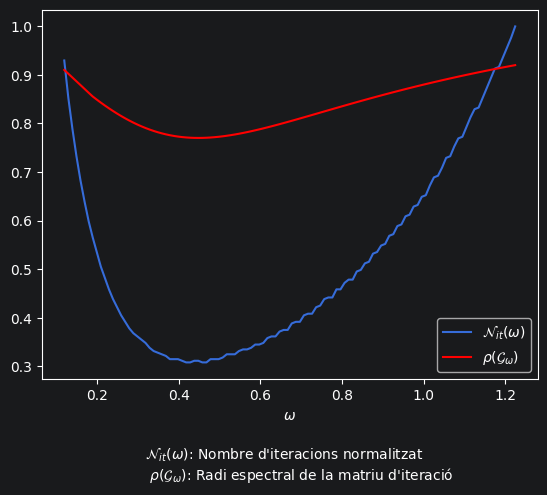

In [8]:
idx = nit > 0

nit_idx = nit[idx]
omega_idx = omega[idx]
rho_idx = rho[idx]

nit_rel= nit_idx / max(nit_idx)        

print(f"dimensions nit: {nit_idx.shape} ")
print(f"dimensions omega: {omega_idx.shape} ")
print(f"dimensions rho: {rho_idx.shape} ")

fig, ax = plt.subplots()

ax.plot(omega_idx, nit_rel, 
        label = '$\\mathcal{N}_{it}(\\omega)$')
ax.plot(omega_idx, rho_idx, 
        label = '$\\rho\\left(\\mathcal{G}_{\\omega}\\right)$',color='red')

plt.xlabel("$\\omega$")
plt.legend(loc = 'lower right')
fig.text(0.5, -0.1,
         " $\\mathcal{N}_{it}(\\omega)$: Nombre d'iteracions normalitzat\n" +
         "\t $\\rho\\left(\\mathcal{G}_\\omega\\right)$: Radi espectral de la matriu d'iteració",
         ha = 'center')
              
plt.show()

In [9]:
from numpy import min
from numpy import argmin

arg_nit_min = argmin(nit_rel, axis = 0)
nit_min = nit_idx[arg_nit_min]
nit_norm_min = nit_rel[arg_nit_min]
omega_min = omega_idx[arg_nit_min]
rho_min = rho_idx[arg_nit_min]

print(f"El mínim nombre d\'iterats: {nit_min:3d}")
print(f"El mínim nombre d\'iterats normalitzat: {nit_norm_min:7.4f}")
print(f"omega que correspon al nombre mínim d'iterats: {omega_min:7.4f}")
print(f"rho que correspon al nombre mínim d'iterats: {rho_min:7.4f}")

El mínim nombre d'iterats:  92
El mínim nombre d'iterats normalitzat:  0.3077
omega que correspon al nombre mínim d'iterats:  0.4179
rho que correspon al nombre mínim d'iterats:  0.7712


### Mètodes del gradient i del gradient conjugat
Vegeu ([[dCNL10]](https://ocw-camins.upc.edu/materials_guia/250402/2023/iterativos_v1.pdf) Seccions 2.2 i 2.3).

__Notació__ 

Sigui $\left\langle\cdot, \cdot\right\rangle$ el producte escalar
ordinari definit a l'espai vectorial real $\R^{n}$, i.e., 
$$
(\xi,\eta)\in\mathbb{R}^{n}\times\mathbb{R}^{n}
            \mapsto\left\langle \xi, \eta \right\rangle 
            = \xi^{\top} \eta = \sum\limits_{i = 1}^{n} \xi_{i}\eta_{i}.
            \tag{1}
$$
__Propietats__
1. $\left\langle \xi, \xi\right\rangle\ge 0$ per a tot $\xi\in\mathbb{R}^{n}$ i
   $\left\langle\xi, \xi\right\rangle = 0$ si i nomé si $\xi = 0$ (positivitat).
2. $\left\langle \xi, \eta\right\rangle =\left\langle \eta, \xi\right\rangle$ per a $\xi,
    \eta\in\mathbb{R}^{n}$ qualsseviol (simetria).  
3. $\left\langle \alpha\xi + \beta\eta, \zeta\right\rangle = \alpha\left\langle
\xi, \zeta \right\rangle + \beta\left\langle \eta, \zeta\right\rangle$, per a
$\xi, \eta,\zeta\in\mathbb{R}^{n}$ qualssevol i per a tot $\alpha,
\beta\in\mathbb{R}$ (linelitat respecte del primer argument).

De fet són les propietats 1, 2, 3, les que defineixen (1) com producte escalar.

També serà útil la propiestat següent. 

 4. $\left\langle \xi, V\eta\right\rangle =\left\langle V^{\top} \xi,
 \eta\right\rangle$, per $\xi, \eta\in\mathbb{R}^{n}$ qualssevol, per a tota
 matriu $V\in M_{n}\left(\mathbb{R}\right)$, i on $V^{\top}$ denota la
 transposada de la matriu $V$.

__Proposició 1__ ([[dCNL10]](https://ocw-camins.upc.edu/materials_guia/250402/2023/iterativos_v1.pdf) Secció 2.1. Proposició 1)

Sigui $A\in M_{n}\left(\mathbb{R}\right)$ matriu simètrica i definida positiva (sdp), $b\in\mathbb{R}$. Aleshores són equivalents:
1. $\mathring{x}\in\mathbb{R}^{n}$ és solució del sistema $Ax = b$.
2. El funcional quadràtic
   $$
    \Phi(x) = \frac{1}{2} \left\langle x, A x\right\rangle 
    - \left\langle x, b\right\rangle, \tag{1}
   $$
   assoleix el seu mínim en $x = \mathring{x}$.

De forma més abreujada escriurem,
$$
 \mathring{x} = A^{-1} b \Longleftrightarrow 
 \underset{x\in\mathbb{R}^{n}}{\operatorname{arg\,min}\,}\Phi(x).
$$ 

__Demostració__

_(i)_ Suposem primer que $\mathring{x}\in\mathbb{R}^{n}$ és solució del sistema
$Ax = b$, i.e., que $A\mathring x = b$ o, equivalentment, 
$$
 A \mathring{x} - b = 0.\tag{2}
$$
Sigui $x\in\R^{n}$, definim $\xi = x - \mathring{x}$. Aleshores,
$$
\begin{align*}
\Phi(x) = \Phi\left(\mathring{x} + \xi\right) 
        &= \frac{1}{2}\left\langle \mathring{x} + \xi, 
                A\left(\mathring{x} + \xi\right)\right\rangle 
            - \left\langle \mathbb{x} + \xi, b\right\rangle\\
        &= \frac{1}{2}\left\langle\mathring{x}, 
                A\mathring{x}\right\rangle 
            + \frac{1}{2}\left\langle \mathring{x}, 
                A\xi\right\rangle 
            + \frac{1}{2}\left\langle\xi, A\mathring{x}\right\rangle 
            + \frac{1}{2}\left\langle \xi, A\xi\right\rangle 
            -\left\langle \mathring{x}, b\right\rangle 
            -\left\langle\xi, b\right\rangle\\ 
        &= \frac{1}{2}\left\langle\mathring{x}, A\mathring{x}\right\rangle 
            -\left\langle\mathring{x}, b\right\rangle 
            + \frac{1}{2}\left\langle\xi, A\xi\right\rangle 
            +\left\langle\xi, A\mathring{x} - b\right\rangle\\
        &= \Phi\left(\mathring{x}\right) 
            + \frac{1}{2}\left\langle\xi, A\xi\right\rangle\\
        &\ge\Phi\left(\mathring{x}\right), \tag{3}
\end{align*}
$$
Això demostra que $\Phi\left(\mathring{x}\right)$ assoleix el seu mínim absolut en
$x = \mathring{x}$.  De fet, donat que $A$ és definida positiva, La igualtat 
es té si i només si $\xi = 0$; això és, si i només si $x = \mathring{x}$.

__Remarca 1:__ Notem que, per arribar a la desigualtat (3), hem fet servir:
1. Que $A$ és definida posiva, per tant $\left\langle\xi, A\xi\right\rangle\ge
0$ per a tot $\xi\in\mathbb{R}^{n}\setminus\{0\}$ i, com ja s'ha
assenyalat, la igualtat resulta si i només si $\xi = x - \mathring{x}$, i.e., si
i només si $x = \mathring{x}$.  
1. Que $\left\langle\xi, A\mathring{x} - b\right\rangle =\left\langle\xi,
0\right\rangle = 0$, atès que $\mathring{x}\in\mathbb{R}^{n}$ és solució del
sistema i llavors satisfà (2).
1. Que $\left\langle\mathbb{x}, A\xi\right\rangle =\left\langle
A^{\top}\mathring{x}, \xi\right\rangle =\left\langle\xi,
A^{\top}\mathring{x}\right\rangle = \left\langle\xi, A\mathring{x}\right\rangle$,
donat que $A$ és simètrica ($A^{\top} = A$).  

_(ii)_ Recíprocament, suposem que $\mathring{x} =
\underset{x\in\mathbb{R}^{n}}{\operatorname{arg\,min}\,}\Phi(x)$. Aleshores
$\mathring{x}$ ha de satisfer la condició necessària d'extrem relatiu, i.e.,
$\nabla\Phi\left(\mathring{x}\right) = 0$. Un càlcul senzill mostra que,
$$
\nabla\Phi\left(x\right) = A x - b.\tag{4} 
$$
En efecte, a partir de l'expressió en components del funcional (1) 
$$
 \Phi(x) = \frac{1}{2}\left\langle x, Ax\right\rangle - 
    \left\langle x, b\right\rangle 
    = \frac{1}{2} x^{\top} A x - x^{\top} b
    = \frac{1}{2}\sum\limits_{i = 1}^{n}\sum\limits_{j = 1}^{n} 
        x_{i} A_{i,j} x_{j} - \sum_{i = 1}^{n} x_{i} b_{i},
$$
si calculem la seva derivada parcial respecte de $x_{k}$ (i.e., la component
$k$-èsima del gradient), resulta
$$
\begin{align*}
   \partial_{k}\Phi (x) &=
    \frac{\partial}{\partial x_{k}}\left(\frac{1}{2}
        \sum_{i = 1}^{n}\sum_{j = 1}^{n} x_{i} A_{i,j} x_{j} 
            - \sum_{i = 1}^{n} x_{i} b_{i}\right)
    = \frac{1}{2}\sum\limits_{i = 1}^{n}\sum\limits_{j = 1}^{n} 
        \left(\delta_{k,i} A_{i,j} x_{j} + x_{i} A_{i,j}\delta_{j,k}\right)
        - \sum_{i = 1}^{n} \delta_{k,i} b_{i}\\
        &= \frac{1}{2}\sum_{j = 1}^{n} A_{k,j} x_{j} 
            +\frac{1}{2}\sum_{i = 1}^{n} x_{i} A_{i,k}
           - b_{k} = \frac{1}{2}\sum_{i = 1}^{n} A_{k,i} x_{i} 
           + \frac{1}{2}\sum_{i = 1}^{n} A^{\top}_{k,i} x_{i} - b_{k}\\
        &= \frac{1}{2}\sum_{i = 1}^{n} A_{k,i} x_{i} 
            + \frac{1}{2}\sum_{i = 1}^{n} A_{k,i}x_{i} - b_{k}
            = \sum_{i = 1}^{n} A_{k,i} x_{i} - b_{k} 
            = \left(A x - b\right)_{k}\tag{$\ast$}
\end{align*}
$$
per a $k=1\div n$, on hem fet servir que $A$ és una matriu simètrica i llavors
$A^{\top}_{k,i} = A_{i,k}$ per $i,k = 1\div n$. Així doncs, la component
$k$-èsima del gradient de $\Phi(x)$ coincideix amb la component $k$-èsima del
vector $A x - b$ per a cada $k = 1\div n$, i d'aquí es segueix (4).

Aleshores, per $x = \mathring{x}$,
$$
 \nabla\Phi\left(\mathring{x}\right) = A \mathring{x} - b = 0.
 $$
Així doncs $\mathring{x}\in\mathbb{R}^{n}$ satisfà (2) i llavors és solució
(única) del sistema $Ax = b$. Això acaba la demostració. 

### Mètode del màxim descens, del gradient, o del pendent màxim 

Sigui $A\in M_{n}\left(\mathbb{R}\right)$ sdp, $b\in\mathbb{R}^{n}$. Considerem el sistema
$$
 A x = b.\tag{5}
$$
El mètode del gradient ve definit per la recurrència,
$$
\left\{
    \begin{align*}
    x_{0} &\in \mathbb{R}^{n},\\
    x_{k+1} &= x_{k} - \alpha_{k}\nabla\Phi\left(x_{k}\right),\qquad k\ge 0.
    \end{align*}
\right.
\tag{6}
$$
D'una banda tenint en compte (4), i si definim $r_{k}$, $k\ge 0$, com el residu de l'aproximació $k$-èsima:
$$ 
r_{k} = b - A x_{k},\qquad k\ge 0,\tag{7} 
$$ 
resulta
$$
    \nabla\Phi\left(x_{k}\right) = b - A x_{k} = - r_{k},\qquad k\ge 0,
    \tag{8}
$$
i aleshores (6) es pot escriure com
$$
\left\{
    \begin{align*}
    x_{0} &\in \mathbb{R}^{n},\\
    x_{k+1} &= x_{k} + \alpha_{k} r_{k},\qquad k\ge 0.
    \end{align*}
\right.\tag{9}
$$
D'altra banda, el pas $\alpha_{k}$ en (7) ó (9) es tria de manera que minimitzi
el funcional quadràtic (1) en la direcció $\nabla\Phi\left(x_{k}\right)$, i.e.,
$$
    \alpha_{k} = \underset{\alpha\in\mathbb{R}}
        {\operatorname{arg\,min}\,}\Phi\left(x_{k} + \alpha r_{k}\right).
$$
Sigui $\xi\in\mathbb{R}^{n}$ donat. Per trobar quin és el valor de $\alpha$,
$\alpha = \alpha_{k}$, que minimitza (1) en la direcció $\xi$, imposem la
condició necessària d'extrem relatiu, 
$$
\begin{align*}
   \left.\frac{\mathrm{d}}{\mathrm{d}\alpha}\right|_{\alpha = \alpha_{k}} 
   \Phi\left(x_{k} + \alpha\xi\right) 
   &= D\Phi\left( x_{k} + \alpha\xi\right)\xi 
        = \left\langle \xi, 
            \nabla\Phi\left(x_{k} + \alpha_{k}\xi\right)\right\rangle\\
   &= \left\langle \xi, A\left( x_{k} + \alpha_{k} \xi\right) - b\right\rangle
        = \left\langle\xi, A x_{k} - b + \alpha_{k}A\xi\right\rangle\\
   &= \left\langle\xi, -r_{k} + \alpha_{k}A\xi\right\rangle
        = -\left\langle\xi,r_{k}\right\rangle 
            +\alpha_{k} \left\langle\xi, A\xi\right\rangle\\
   &= 0.\tag{10}
\end{align*}
$$
Agafant $\xi = r_{k}$ in (10) s'obté,
$$
    \alpha_{k} = \frac{\left\langle r_{k}, r_{k}\right\rangle}
    {\left\langle r_{k}, A r_{k}\right\rangle},\qquad k\ge 0.
    \tag{11}
$$
__Remarca 2__
([[dCNL10]](https://ocw-camins.upc.edu/materials_guia/250402/2023/iterativos_v1.pdf)
Observació 12): D'acord amb (8),
$$
\nabla\Phi\left(x_{k} + \alpha_{k}r_{k}\right)
= \nabla\Phi\left(x_{k+1}\right) = -r_{k+1}
$$
i aleshores de la primera línia de (10), prenent $\xi = r_{k}$ es dedueix que 
$$
   \left\langle r_{k}, r_{k+1}\right\rangle = 0,\qquad k\ge 0.
$$
Això és: a cada iteració, la direcció d'avançament és perpendicular a la
direcció d'avançament de la iteració anterior, la qual cosa fa que, en general,
les direccions d'avançament es repeteixin (per exemple, per $n = 2$, només hi ha
dues direccions d'avançament possibles!) provocant l'alentiment de la
convergència. Vegeu l'exemple 2 al final d'aquest document. 

### Exercici 14
Llegiu la matriu $A$ (simètrica i definida positiva) i el vector $b$ del fitxer
`sistemasdp.npz` amb les instruccions:
```Python
from numpy import load
file = "sistemasdp.npz"
data = load(file)
print(f"Fichero: {file}\nClaves: {data.files}\n")
A = data[data.files[0]]
print(f"Matriu A:\n{A}\n")
b = data[data.files[1]]
print(f"Vector b:\n{b}\n")
data.close() # Cal que tanqueu el fitxer un cop s'han llegit les dades
```
1. Cridem la funció `gradient` per a resoldre el sistema 
$$
     A x = b,
$$
pel mètode del màxim descens, del gradient o del pendent màxim.

2. Amb la instrucció `print` treieu per pantalla almenys les següents dades i resultats: 

    - Les dimensions de les matrius $A$ i $b$.

    - El nombre màxim d'iterats permesos.

    - La precisió demanada, $\varepsilon$. 

    - El nombre d'iterats que s'han executat.
      
    - La norma $2$ del residu de l'última aproximació calculada de la solució.

    - El producte de la precisió, $\varepsilon$, per la norma $2$ de $b$.

    - Quan sigui el cas, un missatge indicant que no s'ha assolit la precisió
      requerida en el nombre d'iterats permesos.


### Solució

In [10]:
# ###################################################################
# Mètode del màxim descens, del gradient, o del pendent màxim
# ###################################################################
from metodes_iteratius import Gradient


tol = 1.0e-14            # Precisió realtiva demanada
nitm = 1000              # Nombre màxim d'iterts permesos
# ###################################################################

A, b = llegir_matrius("sistemasdp.npz")

n = b.shape[0]

print("Amb l'aproximació inicial igual a un vector de zeros:")
gradient = Gradient(tol, nitm)
gradient.resoldre(A, b, np.zeros((n, 1)))
assert gradient.estat is not None
r, num_it_conv = gradient.estat.residu(), gradient.estat.k

imprimir_resultats(gradient)

print()
print("Amb l'aproximació inicial igual a el terme independent:")
gradient = Gradient(tol, nitm)
gradient.resoldre(A, b, b.copy())
assert gradient.estat is not None
r, num_it_conv = gradient.estat.residu(), gradient.estat.k

imprimir_resultats(gradient)

Fichero: data/sistemasdp.npz
Claves: ['matriu_sistema', 'vector']

Dimensions de la matriu A: 50 x 50
Dimensions de la matriu b: 50 x 1

Amb l'aproximació inicial igual a un vector de zeros:
Mètode: Gradient
Nombre màxim d'iterats: nitm = 1000
Precisio: tol = 1.0000e-14

Iterats: 155, ||r|| = 3.25906e-14 < tol * ||b|| = 4.26420e-14

Amb l'aproximació inicial igual a el terme independent:
Mètode: Gradient
Nombre màxim d'iterats: nitm = 1000
Precisio: tol = 1.0000e-14

Iterats: 53, ||r|| = 2.38396e-14 < tol * ||b|| = 4.26420e-14


### Exercici 15
Llegiu la matriu $A$ (simètrica i definida positiva) i el vector $b$ del fitxer
`sistemasdp.npz` amb les instruccions:
```Python
from numpy import load
file = "sistemasdp.npz"
data = load(file)
print(f"Fichero: {file}\nClaves: {data.files}\n")
A = data[data.files[0]]
print(f"Matriu A:\n{A}\n")
b = data[data.files[1]]
print(f"Vector b:\n{b}\n")
data.close() # Cal que tanqueu el fitxer un cop s'han llegit les dades
```
1. Cridem la funció `gradient_conjugat` per a resoldre el sistema 
$$
     A x = b,
$$
pel mètode del gradient conjugat.

2. Amb la instrucció `print` treieu per pantalla almenys les següents dades i resultats: 

    - Les dimensions de les matrius $A$ i $b$.

    - El nombre màxim d'iterats permesos.

    - La precisió demanada, $\varepsilon$. 

    - El nombre d'iterats que s'han executat.
      
    - La norma $2$ del residu de l'última aproximació calculada de la solució.

    - El producte de la precisió, $\varepsilon$, per la norma $2$ de $b$.

    - Quan sigui el cas, un missatge indicant que no s'ha assolit la precisió
      requerida en el nombre d'iterats permesos.


### Solució

In [11]:
from metodes_iteratius import GradientConjugat
# ###################################################################
# Mètode del gradient conjugat
# ###################################################################
tol = 1.0e-14            # Precisió relativa demanada
# Nota: del corol·lari de la proposició 2, tenim que, en aritmètica
# exacta, el mètode dels gradients conjugats convergeix en un màxim
# de n = dim(A) iterats; així que podem definir, un com llegida la
# matriu b:
nitm = len(b) + 10
# ###################################################################

A, b = llegir_matrius("sistemasdp.npz")

n = A.shape[0]

gradient_conjugat = GradientConjugat(tol, nitm)
x0 = np.zeros((n, 1))
gradient_conjugat.resoldre(A, b, x0)

imprimir_resultats(gradient_conjugat)

Fichero: data/sistemasdp.npz
Claves: ['matriu_sistema', 'vector']

Dimensions de la matriu A: 50 x 50
Dimensions de la matriu b: 50 x 1

Mètode: GradientConjugat
Nombre màxim d'iterats: nitm =   60
Precisio: tol = 1.0000e-14

Iterats: 14, ||r|| = 4.70877e-15 < tol * ||b|| = 4.26420e-14


### Exemple 2

Considerem el sistema, $A x = b$, amb
$$ 
   A = \begin{pmatrix}
    3 & 2\\
    2 & 6
   \end{pmatrix},\qquad
   b = \begin{pmatrix}
    \phantom{-}2 \\ -8
   \end{pmatrix}.
$$
Per a visualitzar la convergència dels mètode del gradient i del mètode del
gradient conjugat, representarem al plà $(X,Y)$ les corbes de nivell del
funcional (1) i les iteracions dels dos mètodes$. Vegeu
[[dCNL10]](https://ocw-camins.upc.edu/materials_guia/250402/2023/iterativos_v1.pdf)
Secció 2.3.3.



#### Iteracions del mètode del Gradient

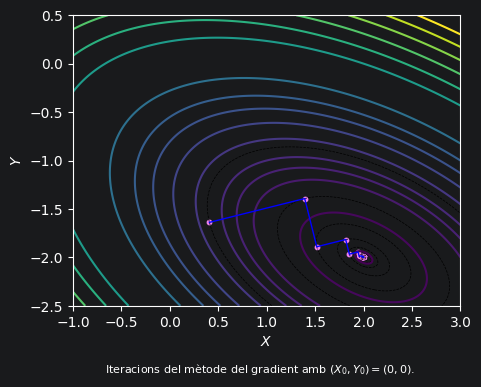

In [12]:
A = array([[3,2],[2,6]], dtype = float64)
b = array([2,-8], dtype = float64)

def Phi(x,y): return  x * A[0,0] * x / 2 +  x * A[0,1] * y + \
    y * A[1,1] * y / 2 - x * b[0] - y * b[1]

# Xarxa de punts
x = linspace(-1, 3, 200)
y = linspace(-2.5, 0.5, 200)
X, Y = meshgrid(x, y)
Z = Phi(X,Y)

# Calculem els iterats  del mètode del gradient conjugat
nitm = 100 
tol = 1.0e-5
tol_rel = tol * np.linalg.norm(b, ord = 2)
z = np.zeros(2).reshape(-1,1)
gradient = Gradient(tol, nitm)
gradient.resoldre(A, b.reshape(-1, 1), z)
z, norm_res, num_it_conv, iterats = gradient.estat.x, gradient.estat.residu(), gradient.estat.k, gradient.estat.iterats

xx = iterats[0,:]
yy = iterats[1,:]
nivells = Phi(xx,yy)

# Corbes de nivell
fig, ax = plt.subplots(figsize = (5, 5))
ax.set_aspect('equal', adjustable='box')
corbes_nivell_iterats = ax.contour(X, Y, Z, levels=sort(nivells),
                                   colors='k', linewidths=0.5)
nivells_de_referencia = [-10, -9.99, -9.5, -8.5, -8.0, -7.5, -6.5,
                         -5.5, -4.5, -3.5, -2.0, 2.0, 4.0, 6.0, 8.0, 
                         10.0, 12.0]
corbes_nivell = ax.contour(X,Y,Z,levels=nivells_de_referencia)

# Dibuixem els iterats del mètode del gradient 
ax.plot(xx,yy,'-',linewidth=1.0,color='blue')
ax.scatter(xx,yy,s=10.0,color='violet')
plt.xlabel('$X$')
plt.ylabel('$Y$')
fig.text(0.5,0.07,
         "Iteracions del mètode del gradient amb $(X_{0}, Y_{0}) = (0,0)$.",
         ha = "center",fontsize=8)
plt.show()

#### Iteracions del mètode del Gradient Conjugat

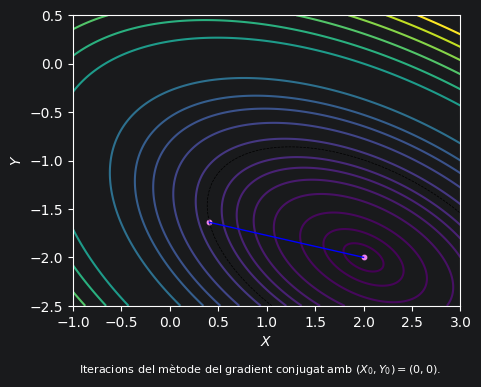

In [13]:
A = array([[3,2],[2,6]], dtype = float64)
b = array([2,-8], dtype = float64)

def Phi(x,y): return  x * A[0,0] * x / 2 +  x * A[0,1] * y + \
    y * A[1,1] * y / 2 - x * b[0] - y * b[1]

# Xarxa de punts
x = linspace(-1, 3, 200)
y = linspace(-2.5, 0.5, 200)
X, Y = meshgrid(x, y)
Z = Phi(X,Y)

# Calculem els iterats del mètode del gradient conjugat
nitm = 10 
tol = 1.0e-10
tol_rel = tol * np.linalg.norm(b, ord = 2)
z = np.zeros(2).reshape(-1,1)

gradient = GradientConjugat(tol, nitm)
gradient.resoldre(A, b.reshape(-1, 1), z)
z, norm_res, num_it_conv, iterats = gradient.estat.x, gradient.estat.residu(), gradient.estat.k, gradient.estat.iterats

xx = iterats[0,:]
yy = iterats[1,:]
nivells = Phi(xx,yy)

# Corbes de nivell
fig, bx = plt.subplots(figsize = (5, 5))
bx.set_aspect('equal', adjustable='box')
corbes_nivell_iterats = bx.contour(X, Y, Z, 
                                   levels=sort(nivells),
                                   colors='k', linewidths=0.5)
nivells_de_referencia = [-10, -9.95, -9.8, -9.5, -9.0, -8.5, -8.0, -7.5,
                         -6.5, -5.5, -4.5, -3.5, -2.0, 2.0, 4.0, 6.0, 8.0, 
                         10.0, 12.0]
corbes_nivell = bx.contour(X,Y,Z,levels=nivells_de_referencia)

# Dibuixem els iterats del mètode del gradient 
bx.plot(xx,yy,'-',linewidth=1.0,color='blue')
bx.scatter(xx,yy,s=10.0,c='violet')
plt.xlabel('$X$')
plt.ylabel('$Y$')
fig.text(0.5,0.07,
    "Iteracions del mètode del gradient conjugat amb $(X_{0}, Y_{0}) = (0,0)$.",ha = "center",fontsize=8)
         
plt.show(fig)